# Le Petit Prince — do better language models predict the **left** hemisphere better?

Hands-on replication of the core result of
**Bonnasse-Gahot & Pallier (2024)**, *fMRI predictors based on language models of
increasing complexity recover brain left lateralization* ([arXiv:2405.17992](https://arxiv.org/abs/2405.17992)),
on the *average subject* of the Le Petit Prince fMRI corpus.

**The pipeline**

1. `Li2022PetitAverage` study → word events + BOLD, 9 runs.
2. Word-level features from a language model.
3. Convolve with the haemodynamic response and resample to the fMRI TR.
4. Ridge encoding, leave-one-run-out → one Pearson *r* per voxel.
5. Compare left vs right hemisphere.

**Before you start:** run the setup cell below. On Colab it installs everything
for you; locally, follow `README.md` first (`uv pip install -e .`).

**Runtime: about 15 minutes end to end**, most of it the one-off 700 MB data
download. The language-model features come precomputed (43 MB), because running
eleven models over 15,406 words in context would take hours on a CPU. Everything
else — the regression, the statistics, the figures — runs on your machine. Set
`USE_PRECOMPUTED = False` in section 3 to do the extraction yourself; that wants
a GPU.

In [1]:
# ---------------------------------------------------------------------------
# Setup. On Google Colab this installs everything and fetches the repository.
# Running locally, it does nothing: you already did `uv pip install -e .`.
# ---------------------------------------------------------------------------
REPO_URL = "https://github.com/BelCorentin/lpp-lateralization-workshop"

import os
import subprocess
import sys

if "google.colab" in sys.modules:
    # Colab already ships a CUDA torch; installing only what is missing keeps
    # this to ~1 minute and avoids a runtime restart.
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "neuralset>=0.2.3",
         "neuralfetch>=0.2.3", "transformers", "praatio", "nilearn", "plotly"],
        check=True,
    )
    name = REPO_URL.rstrip("/").split("/")[-1]
    if not os.path.isdir(name):
        subprocess.run(["git", "clone", "-q", REPO_URL], check=True)
    os.chdir(name)
    sys.path.insert(0, os.getcwd())
    print("Colab setup done, working in", os.getcwd())
else:
    import lppws  # noqa: F401  -- fails here if `pip install -e .` was skipped
    print("Local install detected")

Local install detected


## 0. Setup

In [2]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

from lppws.study import Li2022PetitAverage, download_data
from lppws import pipeline as pl

# Resolve paths against the repository root, so the notebook works whether the
# kernel starts in `notebooks/` (JupyterLab's default) or at the top level.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()),
            Path.cwd())
DATA_DIR = Path(os.environ.get("LPP_DIR", ROOT / "data" / "lpp_average_subject_en"))
if not DATA_DIR.exists():
    DATA_DIR = download_data(DATA_DIR.parent)     # ~700 MB, resumable
CACHE = ROOT / "cache"          # feature cache: recomputing embeddings is the slow part

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("root:  ", ROOT)
print("data:  ", DATA_DIR.resolve())
print("device:", DEVICE)
if DEVICE == "cpu":
    print("  (no GPU: fine — the heavy features are precomputed. On Colab you can\n"
          "   get one with Runtime > Change runtime type > T4 GPU.)")

root:   /home/co/git/lpp-lateralization-workshop
data:   /home/co/tmp/li-avg/lpp_average_subject_en
device: cuda


## 1. From a folder on disk to a table of events

This is the part worth understanding, because everything after it is ordinary
statistics.

On disk, this dataset is two completely different things: nine 4-D NIfTI files
(the brain volumes) and nine Praat `.TextGrid` files (when each word was
spoken). Different formats, different tools, different conventions.

`neuralset` hides that behind one idea: **a `Study` reads a folder and gives
you a single table in which every row is an _event_** — something that happened
at a time. A word is an event. The whole fMRI recording is an event too. Each
row has a `type`, a `start` and a `duration`, so a spoken word and a brain scan
can sit in the same table and be lined up on the same clock.

Two words of vocabulary:

* a **timeline** is one continuous recording. Here there are nine, one per
  section of the story. Trials, runs, blocks, sessions — all timelines.
* the **query** picks which ones you want. `"timeline_index < 9"` takes all
  nine; `"timeline_index < 1"` would give you a single run to test on.

The payoff is that the analysis below never mentions NIfTI or TextGrid. Swap
`Li2022PetitAverage` for another study in `neuralfetch` — an EEG or MEG corpus,
a different fMRI dataset — and you get a table with these same columns.

In [3]:
study = Li2022PetitAverage(path=str(DATA_DIR), query="timeline_index < 9")
events = study.run()

timelines = list(dict.fromkeys(events["timeline"]))   # 9 runs, in order
print(f"{len(events)} events across {len(timelines)} runs")
print(events["type"].value_counts().to_dict())
events[["type", "start", "duration", "text", "timeline"]].head()

15415 events across 9 runs
{'Word': 15406, 'Fmri': 9}


,type,start,duration,text,timeline
0,Fmri,0.000000,564.000000,NaN,"Li2022PetitAverage:lang=EN,run=1,subject=sub-a..."
1,Word,0.113200,0.615000,once,"Li2022PetitAverage:lang=EN,run=1,subject=sub-a..."
2,Word,0.728200,0.191208,when,"Li2022PetitAverage:lang=EN,run=1,subject=sub-a..."
3,Word,0.919408,0.105479,i,"Li2022PetitAverage:lang=EN,run=1,subject=sub-a..."
4,Word,1.024887,0.133313,was,"Li2022PetitAverage:lang=EN,run=1,subject=sub-a..."


Read the output above: **15,406 `Word` events and 9 `Fmri` events**, across 9
timelines. The nine `Fmri` rows are not a mistake — one whole 4-D recording is
*one* event, and its `filepath` column says where the voxels live. Only the
things you actually need in memory get loaded, and only when you ask.

Useful columns: `type`, `start`, `duration`, `timeline`, `text` (the word),
`filepath` (for data-bearing events), `context` (empty for now — we fill it in
section 7).

### What is in the whole study?

`neuralset` ships its own views in `neuralset.events.viz`. `plot_study` gives a
treemap of *study → subject → timeline*, with each rectangle sized by duration.
One glance tells you how much data you have and how it is split.

In [4]:
from neuralset.events import viz

viz.plot_study(events)     # hover a rectangle for its exact duration

### What is inside one timeline?

`plot_events` draws one recording as horizontal bars, one row per event type.

Two practical notes. It makes **one bar per event**, so handing it all 1,517
words of a run produces a huge, slow figure — we pass a 30-second slice
instead. And the `Fmri` event lasts the whole 564-second run, which would
stretch the x-axis and squash the words into a sliver, so we set the range
explicitly.

In [5]:
run1 = events[events.timeline == timelines[0]]
slice30 = run1[(run1.start < 30) | (run1.type == "Fmri")]

fig = viz.plot_events(slice30)
fig.update_xaxes(range=[0, 30])          # the Fmri bar spans the full run
fig.update_layout(height=320, title_text="Run 1, first 30 seconds")
fig

The `Fmri` bar runs across the whole window: the scanner never stops. The
`Word` bars underneath are the story arriving. Now zoom in far enough to read
them, and draw the fMRI sampling grid on top.

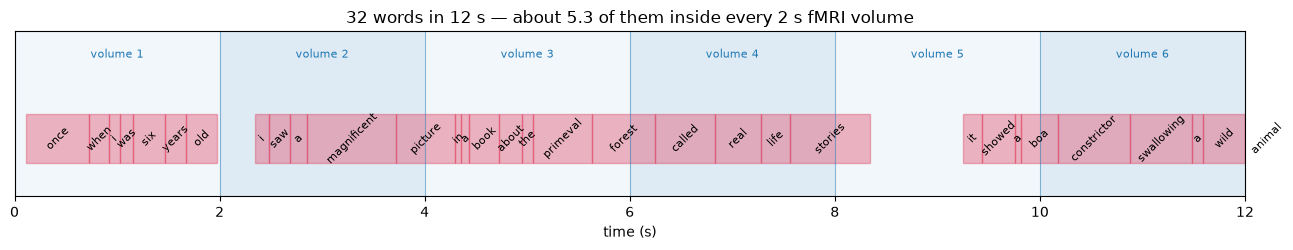

In [6]:
from lppws.viz import plot_word_timing

plot_word_timing(events, timelines[0], t0=0, t1=12)
plt.tight_layout(); plt.show()

### The problem this creates

You should recognise the text — it is the opening of the book.

Look at the timescales. Words arrive at **2.7 per second** (median word: 0.23 s).
The scanner produces **one volume every 2 seconds**. So roughly **5.5 words
land inside every single brain sample**: 15,406 words against 2,816 volumes.

The brain data cannot follow the words one by one, and nothing in this table
fixes that. Worse, the BOLD response to a word does not even appear until
several seconds *after* it — it is a slow, smeared echo of neural activity.

Sections 2 and 3 deal with exactly this: turn the word events into a signal
sampled on the scanner's clock, blurred the way the brain blurs it.

## 2. The fMRI target — mask, hemispheres, mirror homologs

`load_brain` fits a nilearn masker on the study's own `mask_lpp_en.nii.gz`
(detrending, standardisation, 1/128 Hz high-pass) and works out, for every
voxel, its MNI *x* coordinate (→ hemisphere) and the index of its **mirror
homolog** in the other hemisphere. The homolog is what makes the lateralization
measure a *paired* comparison later on.

In [7]:
brain = pl.load_brain(next(DATA_DIR.glob("**/mask_lpp_en.nii.gz")))
print(f"voxels={brain.n_voxels}  left={brain.left.sum()}  right={brain.right.sum()}"
      f"  with a mirror homolog: {brain.valid.mean():.0%}")

# (n_TR, n_voxels) per run. ~1 min: 9 x ~65 MB of NIfTI.
bold = {tl: pl.load_bold(brain, events, tl) for tl in timelines}
{tl.split(',')[-1]: Y.shape for tl, Y in list(bold.items())[:3]}

voxels=25870  left=12425  right=12425  with a mirror homolog: 100%


/home/co/git/lpp-lateralization-workshop/lppws/pipeline.py:80: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  return brain.masker.transform(fp)


{'subject=sub-avgEN': (340, 25870)}

In [8]:
# The 7 left-hemisphere language-network ROIs shipped with the data.
rois = pl.roi_membership(next(DATA_DIR.glob("**/roi_masks")), brain)
lang_left = np.zeros(brain.n_voxels, bool)
for m in rois.values():
    lang_left |= m
print({k: int(v.sum()) for k, v in rois.items()}, "-> union:", int(lang_left.sum()), "voxels")

{'AG_TPJ': 56, 'BA44': 56, 'BA45': 53, 'BA47': 81, 'TP': 59, 'aSTS': 56, 'pSTS': 69} -> union: 430 voxels


## 3. Predictors — word features → HRF → design matrix

`HuggingFaceText` emits one embedding per word. Because the words carry onsets,
the result is a *timed signal*, which `HrfConvolve` blurs with the
haemodynamic response and resamples to the fMRI TR — turning 15,406 word
vectors into 2,816 rows, one per acquired volume. That is the fix for the
timescale mismatch from section 1.

### Two ways to get there

Running a language model over 15,406 words in context is the only expensive
step in this notebook: a couple of minutes per model on a GPU, but **close to an
hour per model** on the 2-vCPU machine a free Colab session usually gives you.
With eleven models that is a non-starter for a workshop.

So the design matrices are precomputed and published, and downloading them takes
about ten seconds. **Nothing else is skipped** — the ridge regression, the
lateralization and the statistics all still run on your machine. They reproduce
the GPU pipeline to five decimal places.

Set `USE_PRECOMPUTED = False` to extract everything yourself; the live code is
right there in `features_for` below, and it is what produced the pack.

In [9]:
from lppws import cached

# Each Word gets its running context (last 32 words, ending with itself), so a
# model can embed it *in context* rather than as a dictionary entry.
ctx_events = pl.add_running_context(events, timelines, n_words=32)

USE_PRECOMPUTED = True     # False -> run the language models yourself
FIT_SWEEPS_LIVE = False    # True  -> refit the ridge for all 14 configs (~15 min+)

if DEVICE == "cpu" and not USE_PRECOMPUTED:
    print("WARNING: no GPU. Extracting all models here will take hours.\n"
          "On Colab: Runtime > Change runtime type > T4 GPU, or keep "
          "USE_PRECOMPUTED = True.")

FEATURES = cached.load_features(timelines, cache_dir=CACHE) if USE_PRECOMPUTED else {}
FOLDS = {} if FIT_SWEEPS_LIVE else cached.load_folds(cache_dir=CACHE)

def features_for(tag, model, *, contextualized=True, layers=2/3, revision=None):
    """Design matrices for one model config: {timeline: (n_TR, n_features)}."""
    if USE_PRECOMPUTED:
        return FEATURES[tag]
    kw = {}
    if revision:
        from neuralset.extractors.text import HuggingFaceTextConfig
        kw["hf_config"] = HuggingFaceTextConfig(model_kwargs={"revision": revision})
    ev = ctx_events if contextualized else events
    h = pl.hf_features(ev, model, contextualized=contextualized, layers=layers,
                       device=DEVICE, cache_dir=CACHE, **kw)
    return {tl: pl.design_matrix(h, ev, tl) for tl in timelines}

def folds_for(tag, model, **kw):
    """The 9 held-out-run encoding maps for one config, fitted or loaded."""
    if not FIT_SWEEPS_LIVE:
        return FOLDS[tag]
    return pl.encode_corr_from_X(features_for(tag, model, **kw), timelines, bold,
                                 per_fold=True)

for tag, what in cached.TAGS.items():
    print(f"  {tag:16s} {what}")

  gpt2-static      gpt2, non-contextual (a lexicon lookup), layer 2/3
  size-14m         pythia-14m, contextual, layer 2/3
  size-70m         pythia-70m, contextual, layer 2/3
  size-160m        pythia-160m, contextual, layer 2/3
  size-410m        pythia-410m, contextual, layer 2/3
  step-1           pythia-70m at random initialisation
  step-512         pythia-70m after 512 training steps
  step-2000        pythia-70m after 2 000 training steps
  step-8000        pythia-70m after 8 000 training steps
  step-32000       pythia-70m after 32 000 training steps
  step-143000      pythia-70m fully trained
  gpt2-layer-33    gpt2 contextual, layer 1/3
  gpt2-layer-66    gpt2 contextual, layer 2/3
  gpt2-layer-100   gpt2 contextual, last layer


In [10]:
X_static = features_for("gpt2-static", "openai-community/gpt2", contextualized=False)

print("design matrix for run 1:", X_static[timelines[0]].shape, " (n_TR, n_features)")
print("BOLD for run 1:        ", bold[timelines[0]].shape)

design matrix for run 1: (282, 768)  (n_TR, n_features)
BOLD for run 1:         (282, 25870)


## 4. Ridge encoding, leave-one-run-out

For each of the 9 runs: fit ridge on the other 8, predict the held-out run,
correlate prediction with the real BOLD, per voxel. The 9 correlation maps are
averaged.

The ridge penalty is chosen by `RidgeCV` **inside the training runs only**.
Selecting it on the held-out run is a classic and large source of inflation.

In [11]:
# per_fold=True keeps the 9 held-out-run maps; we need them for a real error bar.
r_static_folds = pl.encode_corr_from_X(X_static, timelines, bold, per_fold=True)
r_static = r_static_folds.mean(0)
print(f"per-fold maps: {r_static_folds.shape}")
print(f"mean encoding r over {brain.n_voxels} voxels: {r_static.mean():.4f}")

per-fold maps: (9, 25870)
mean encoding r over 25870 voxels: 0.0266


## 5. Left vs right

Two ways to ask the question:

* **Unpaired** — mean *r* over all left voxels vs all right voxels.
* **Paired** — for each left voxel, its *r* minus the *r* of its right mirror
  homolog. This cancels any global shift in fit quality and is much more
  sensitive.

In [12]:
L, R, li = pl.hemisphere_means(r_static, brain)
print(f"unpaired:  L={L:.4f}  R={R:.4f}   (L-R)/(|L|+|R|) = {li:+.3f}")

d_all = pl.paired_lateralization(r_static, brain)                # all left voxels
d_lang = pl.paired_lateralization(r_static, brain, lang_left)    # language ROIs only
for name, d in [("whole brain", d_all), ("language ROIs", d_lang)]:
    m, lo, hi = pl.bootstrap_ci(d)
    print(f"paired {name:14s}: {m:+.4f}  [{lo:+.4f}, {hi:+.4f}]  (n={d.size} voxels)")

unpaired:  L=0.0286  R=0.0253   (L-R)/(|L|+|R|) = +0.062
paired whole brain   : +0.0034  [+0.0028, +0.0040]  (n=12425 voxels)
paired language ROIs : -0.0040  [-0.0068, -0.0012]  (n=430 voxels)


### How wrong is that confidence interval?

Very. There is only **one subject** here (49 people averaged into one), so the
bootstrap above resamples *voxels*. Neighbouring voxels in a smoothed fMRI map
are strongly correlated, so 430 voxels are nowhere near 430 independent
observations and the interval comes out far too narrow.

A better-behaved (still not perfect) error bar uses the spread **across the 9
held-out runs**: compute the lateralization separately in each fold and look at
how much it moves. The folds share 8/9 of their training data, so this is not a
clean significance test either — but it is the right order of magnitude.


In [13]:
for name, subset in [("whole brain", None), ("language ROIs", lang_left)]:
    v = pl.across_run_ci(r_static_folds, brain, subset)
    print(f"{name:14s}: {v['mean']:+.4f}  [{v['lo']:+.4f}, {v['hi']:+.4f}]"
          f"   positive in {v['runs_positive']}/{v['n_runs']} runs")


whole brain   : +0.0034  [+0.0003, +0.0064]   positive in 6/9 runs
language ROIs : -0.0040  [-0.0142, +0.0061]   positive in 4/9 runs


## 6. Where in the brain?

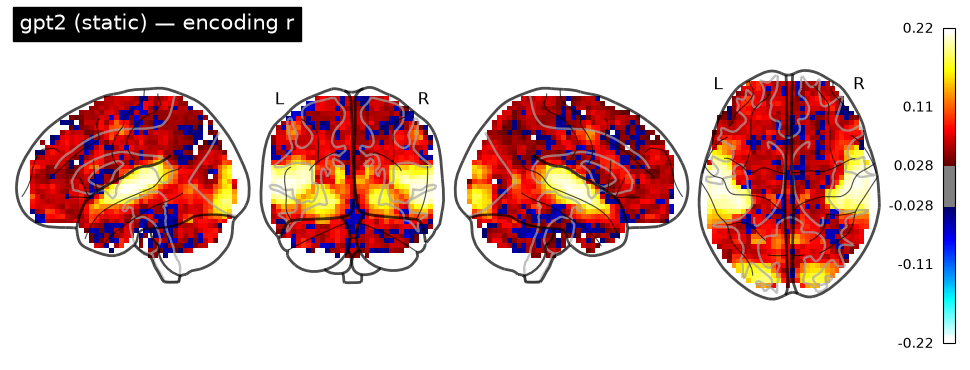

In [14]:
from nilearn import plotting

img = brain.masker.inverse_transform(r_static)
plotting.plot_glass_brain(img, display_mode="lyrz", colorbar=True, plot_abs=False,
                          cmap="cold_hot", title="gpt2 (static) — encoding r")
plotting.show()

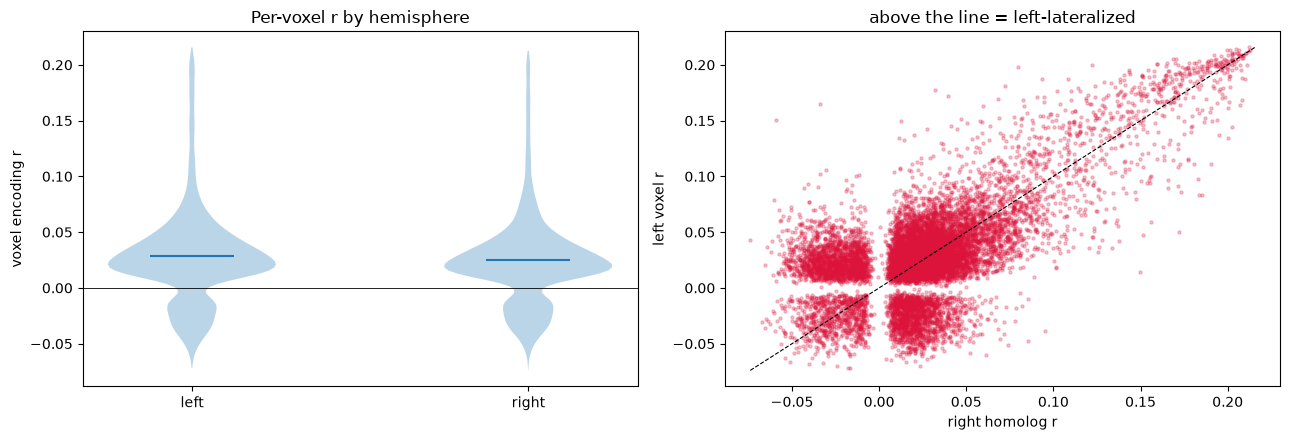

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].violinplot([r_static[brain.left], r_static[brain.right]], showmeans=True, showextrema=False)
ax[0].set_xticks([1, 2]); ax[0].set_xticklabels(["left", "right"])
ax[0].axhline(0, color="k", lw=0.6); ax[0].set_ylabel("voxel encoding r")
ax[0].set_title("Per-voxel r by hemisphere")

sel = brain.left & brain.valid
ax[1].scatter(r_static[brain.pair[sel]], r_static[sel], s=5, alpha=0.25, color="crimson")
lim = [float(min(r_static.min(), 0)), float(r_static.max())]
ax[1].plot(lim, lim, "k--", lw=0.8)
ax[1].set_xlabel("right homolog r"); ax[1].set_ylabel("left voxel r")
ax[1].set_title("above the line = left-lateralized")
plt.tight_layout(); plt.show()

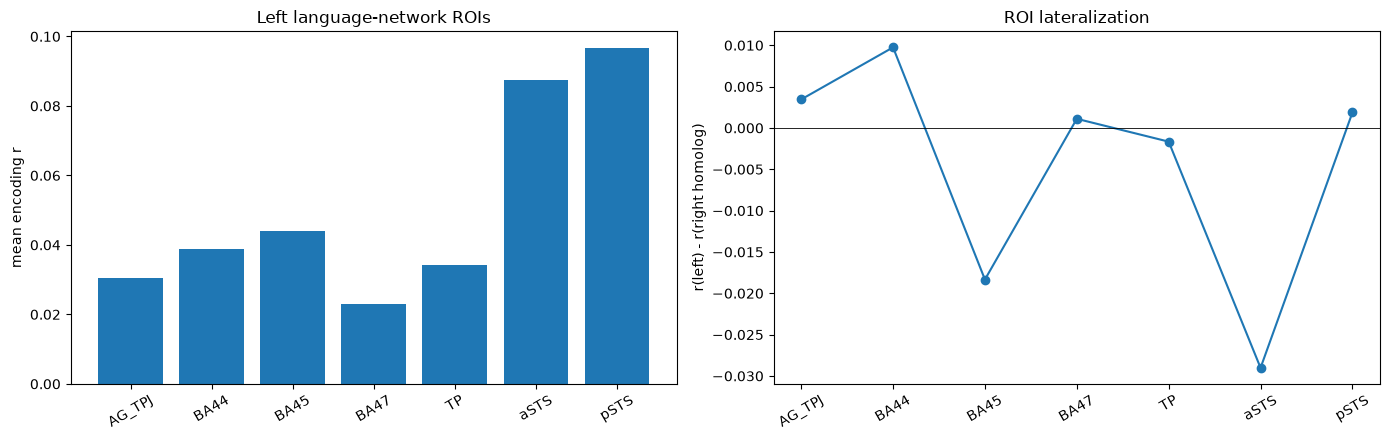

In [16]:
# Per-ROI: encoding quality, and each left ROI against its right-hemisphere homolog.
names = list(rois)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(names, [r_static[m].mean() for m in rois.values()])
ax[0].set_ylabel("mean encoding r"); ax[0].set_title("Left language-network ROIs")
ax[0].tick_params(axis="x", rotation=30)

ax[1].plot(names, [pl.paired_lateralization(r_static, brain, m).mean() for m in rois.values()], "o-")
ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_ylabel("r(left) - r(right homolog)"); ax[1].set_title("ROI lateralization")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## 7. Does the asymmetry grow with model size?

This is the paper's claim. Two changes make the test sensitive:

1. **Contextual embeddings** — each word is embedded *inside* its running
   context, so the features carry sentence-level information rather than a
   lexicon lookup.
2. **A sweep** over Pythia model sizes (14m → 410m), all at the same final
   checkpoint.

The first run downloads several checkpoints and recomputes embeddings — minutes
and a few GB, then cached in `CACHE`. 410m is the largest that comfortably fits
8 GB of GPU memory.

In [17]:
import pandas as pd

print("one context string looks like:")
print(" ", repr(ctx_events.query("type=='Word'")["context"].iloc[20]))

one context string looks like:
  'once when i was six years old i saw a magnificent picture in a book about the primeval forest called real'


In [18]:
SIZES = {"14m": "EleutherAI/pythia-14m", "70m": "EleutherAI/pythia-70m",
         "160m": "EleutherAI/pythia-160m", "410m": "EleutherAI/pythia-410m"}
NPARAMS = {"14m": 1.4e7, "70m": 7e7, "160m": 1.6e8, "410m": 4.1e8}

folds = {tag: folds_for(f"size-{tag}", model) for tag, model in SIZES.items()}
results = {t: f.mean(0) for t, f in folds.items()}

df = pd.DataFrame({t: pl.metrics(r, brain, lang_left) for t, r in results.items()}).T
df = df.join(pd.DataFrame({t: pl.across_run_ci(f, brain, lang_left) for t, f in folds.items()}).T
             .rename(columns=lambda c: f"run_{c}"))
df

,mean_r,LI_global,LI_lang,LI_lang_lo,LI_lang_hi,run_mean,run_lo,run_hi,run_n_runs,run_runs_positive
14m,0.033668,0.004506,0.002607,-0.000113,0.005367,0.002607,-0.006402,0.011615,9.0,5.0
70m,0.035684,0.004479,0.003324,0.000383,0.006127,0.003324,-0.008375,0.015023,9.0,5.0
160m,0.036323,0.004468,0.002558,-0.000468,0.005522,0.002558,-0.009677,0.014793,9.0,5.0
410m,0.036770,0.005004,0.005942,0.002685,0.009076,0.005942,-0.006028,0.017913,9.0,6.0


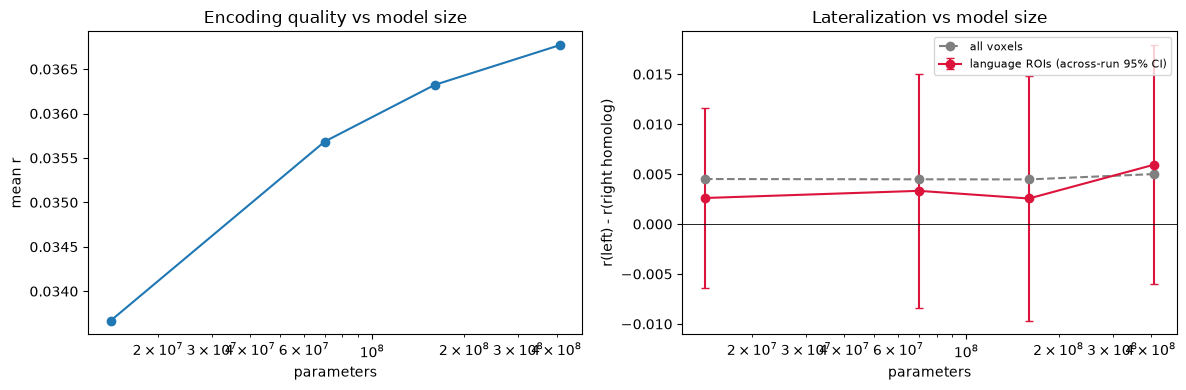

In [19]:
xs = [NPARAMS[t] for t in df.index]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(xs, df["mean_r"], "o-")
ax[0].set_xscale("log"); ax[0].set_xlabel("parameters"); ax[0].set_ylabel("mean r")
ax[0].set_title("Encoding quality vs model size")

yerr = np.array([df["run_mean"] - df["run_lo"], df["run_hi"] - df["run_mean"]])
ax[1].errorbar(xs, df["run_mean"], yerr=yerr, fmt="o-", color="crimson", capsize=3,
               label="language ROIs (across-run 95% CI)")
ax[1].plot(xs, df["LI_global"], "o--", color="gray", label="all voxels")
ax[1].set_xscale("log"); ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_xlabel("parameters"); ax[1].set_ylabel("r(left) - r(right homolog)")
ax[1].set_title("Lateralization vs model size"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 8. The clean complexity axis: **training**

The size sweep above has a problem. Every model was read at the same *relative*
depth, and different architectures put different things at 2/3 of their depth —
so "size" and "which layer we happened to read" vary together. Section 9 shows
how large that confound is.

The training axis has no such problem. Pythia publishes intermediate checkpoints
of the *same* network: same architecture, same width, same layer index, only the
weights differ. Anything that moves along this axis moves because the model
learned, not because we changed where we read.

We take one small model — **pythia-70m** — from random initialisation
(`step1`) to fully trained (`step143000`).

In [20]:
STEPS = [1, 512, 2000, 8000, 32000, 143000]   # valid Pythia revisions

step_folds = {st: folds_for(f"step-{st}", "EleutherAI/pythia-70m", revision=f"step{st}")
              for st in STEPS}

pd.DataFrame({st: pl.metrics(f.mean(0), brain, lang_left)
              for st, f in step_folds.items()}).T[["mean_r", "LI_global", "LI_lang"]]

,mean_r,LI_global,LI_lang
1,0.026461,0.002804,-0.004698
512,0.026786,0.003489,-0.003606
2000,0.028738,0.003653,-0.002385
8000,0.033343,0.004676,0.001701
32000,0.035159,0.004610,0.003102
143000,0.035684,0.004479,0.003323


### Testing the *trend*, not the points

Each individual checkpoint's lateralization has a wide across-run interval — as
it did in section 5. But the claim is not "this checkpoint is lateralized", it
is "**lateralization grows with training**", and that is a much easier thing to
test: within one held-out run, compare that run against *itself* across
checkpoints. The run's own noise cancels out of its slope.

`trend_test` fits a line per run and tests the 9 slopes against zero.

In [21]:
for metric, subset, label in [("mean_r", None, "encoding quality"),
                              ("LI", None, "lateralization, whole brain"),
                              ("LI", lang_left, "lateralization, language ROIs")]:
    tr = pl.trend_test(step_folds, brain, subset=subset, metric=metric)
    print(f"{label:32s} slope/decade={tr['slope']:+.5f}  t={tr['t']:+.2f}  "
          f"p={tr['p']:.2g}  up in {tr['runs_positive']}/{tr['n_runs']} runs")
    print(f"{'':32s} curve: " + "  ".join(f"{v:+.4f}" for v in tr['curve']))

encoding quality                 slope/decade=+0.00214  t=+5.52  p=0.00056  up in 9/9 runs
                                 curve: +0.0265  +0.0268  +0.0287  +0.0333  +0.0352  +0.0357
lateralization, whole brain      slope/decade=+0.00041  t=+1.85  p=0.1  up in 7/9 runs
                                 curve: +0.0028  +0.0035  +0.0037  +0.0047  +0.0046  +0.0045
lateralization, language ROIs    slope/decade=+0.00186  t=+4.11  p=0.0034  up in 8/9 runs
                                 curve: -0.0047  -0.0036  -0.0024  +0.0017  +0.0031  +0.0033


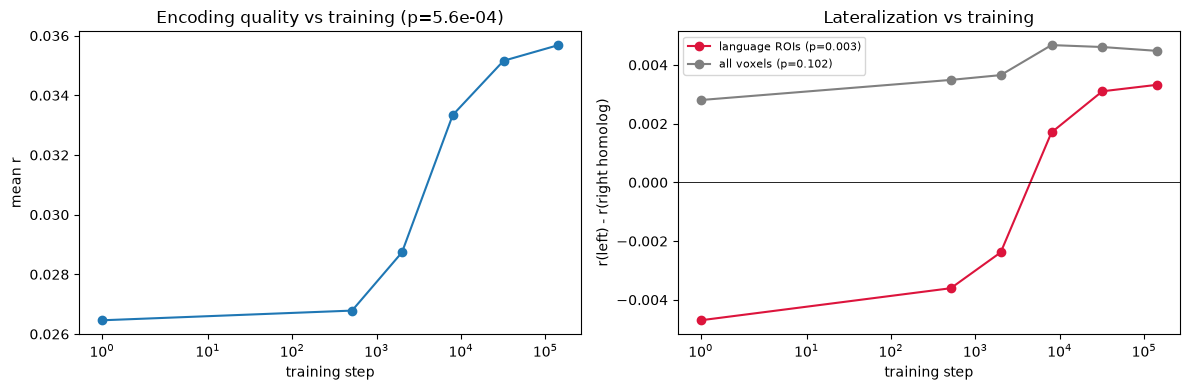

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
mr = pl.trend_test(step_folds, brain, metric="mean_r")
ax[0].plot(STEPS, mr["curve"], "o-")
ax[0].set_xscale("symlog"); ax[0].set_xlabel("training step"); ax[0].set_ylabel("mean r")
ax[0].set_title(f"Encoding quality vs training (p={mr['p']:.1e})")

for subset, lbl, col in [(lang_left, "language ROIs", "crimson"), (None, "all voxels", "gray")]:
    tr = pl.trend_test(step_folds, brain, subset=subset)
    ax[1].plot(STEPS, tr["curve"], "o-", color=col, label=f"{lbl} (p={tr['p']:.3f})")
ax[1].set_xscale("symlog"); ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_xlabel("training step"); ax[1].set_ylabel("r(left) - r(right homolog)")
ax[1].set_title("Lateralization vs training"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

On our run: encoding quality **+0.0021 per decade of training**
(t=+5.5, p=0.0006, up in 9/9 runs) and language-ROI lateralization
**+0.0019 per decade** (t=+4.1, p=0.003, up in 8/9 runs), going from
−0.0047 at random initialisation to +0.0033 fully trained — it *crosses zero*.
The whole-brain effect rises early and then plateaus (p=0.10).

That is the paper's claim, on a 70M-parameter model, with no layer confound.
Note which measure moves: training makes the **language network specifically**
more left-lateralized, while the global asymmetry saturates almost immediately.

## 9. Which layer? (why the size axis is harder)

Everything above read every model at the same *relative* depth, `layers=2/3`.
That choice is not innocent. Sweep it on a single model and compare the spread
you get to the spread the whole size sweep gave you.

In [23]:
layer_rows = {}
for tag, lay in [("gpt2-layer-33", 1/3), ("gpt2-layer-66", 2/3), ("gpt2-layer-100", 1.0)]:
    f = folds_for(tag, "openai-community/gpt2", layers=lay)
    layer_rows[round(lay, 2)] = pl.metrics(f.mean(0), brain, lang_left)

pd.DataFrame(layer_rows).T[["mean_r", "LI_global", "LI_lang"]]

,mean_r,LI_global,LI_lang
0.33,0.036472,0.004517,0.004204
0.67,0.018042,0.000519,-0.001867
1.00,0.024782,0.002043,-0.007971


On our run this moved `mean r` from 0.037 (layer 1/3) to 0.018 (layer 2/3) and
flipped the sign of the language-ROI lateralization — a bigger swing than the
entire 14m → 410m size sweep produced. See `RESULTS.md` for the numbers.

The practical consequence: a size or training-step curve read at one fixed
relative depth is confounded with where that depth lands inside each network.
Sweep layers first, or report the curve at each model's best layer.

## 10. Where to go next

* **The other checkpoints.** Pythia publishes far more revisions than the six
  used here (`step1000`, `step3000`, ... up to `step143000`). A denser training
  curve costs only compute.
* **Training x size.** Repeat section 8 for `pythia-14m` and `pythia-160m` and
  ask whether the *slope* of the training effect itself grows with size. That
  question is layer-confound-free, unlike comparing sizes at one checkpoint.
* **Best-layer size sweep.** If you do want the size axis, sweep layers for each
  model and compare like with like (see `RESULTS.md`).
* **Context length.** `n_words` in `add_running_context` trades context richness
  against compute.
* **Bigger models** (`pythia-1b`, `1.4b`, `2.8b`) on a machine with more memory.
* **A real error bar.** Everything here rests on 9 runs of *one* averaged
  subject. Rerun on the per-subject data (`Li2022Petit` from `neuralfetch`,
  OpenNeuro ds003643) and bootstrap over subjects.